In [1]:
import medal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import shap
import torch.nn as nn
import torch

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from functools import partial

/insomnia001/depts/iicd/users/vj2308/miniconda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-01 12:53:02,248	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-07-01 12:53:03,626	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [14]:
### data simulation
np.random.seed(40)
def generate_onion_correlation_matrix(d):
    R=np.zeros((d,d))
    R[0,0]=1.0

    for k in range(1, d):
        beta=(d-k) / 2.0
        y=np.random.beta(beta, beta)
        
        r=2*y-1
        
        w=np.random.normal(size=k)
        w=w/np.linalg.norm(w)
        
        P=np.sqrt(1-r**2)*w
        sub_matrix=R[:k, :k]
        U=np.linalg.cholesky(sub_matrix)
        c=U@P
        R[k, :k]=c
        R[:k, k]=c
        R[k, k]=1.0        
    return R
def build_covariance_matrix(d, std_devs):
    R=generate_onion_correlation_matrix(d)
    D=np.diag(std_devs)
    
    #covariance
    sigma=D@R@D
    return sigma
def random_orthonormal_svd(n, m):
    np.random.seed(42)
    H=np.random.randn(m, n)
    U, S, Vt=np.linalg.svd(H, full_matrices=False)
    return U @ Vt #high_d x low_d
def append_noise(sample_size, noise_size):
    #add random noise feature
    # rng=np.random.default_rng(seed=67+i)
    noise=np.random.normal(size=(sample_size,noise_size))
    return noise

def build_simple_k_clusters(k, sample_size, signal_d, noise_d):
    rng=np.random.default_rng(seed=71)
    samp_list=[sample_size//k for i in range(k)]
    samp_list[-1]+=sample_size%k

    dataset = np.empty((0, signal_d+noise_d))
    labels = np.array([i for i in range(k) for j in range(samp_list[i])])
    mu = rng.uniform(low=-k, high=k, size=(k, signal_d))
    for i in range(k):
        samp = samp_list[i]
        stdv=rng.uniform(low=0.5,high=0.6,size=signal_d) 
        cov_matrix=build_covariance_matrix(signal_d, stdv)
        x0=rng.multivariate_normal(mu[i,:], cov_matrix, samp) #( samp, signal_d)
        xnoise = append_noise(samp, noise_d) #(samp, noise_d)
        dataset = np.vstack((dataset, np.hstack((x0, xnoise)))) # (sample_size, signal_d+noise_d)
    return dataset, labels, mu, samp_list

In [3]:
def plot_pca(x_pca,labels):
    df_pca=pd.DataFrame(data=x_pca, columns=["pc1","pc2"])
    df_pca["labels"]=labels

    sns.scatterplot(
        x="pc1",
        y="pc2",
        data=df_pca,
        hue="labels",
        palette="Set1")

def plot_signal_noise(X,y):
    X_pca = PCA(n_components=2).fit_transform(X[:,:10]) # only signal data
    
    X_pca_noise = PCA(n_components=2).fit_transform(X[:,10:]) #only noise data
    
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y) # This should have structure
    plt.show()
    plt.scatter(X_pca_noise[:,0], X_pca_noise[:,1], c=y) # This should NOT Have structure

def recon_loss_pca(pca, x_og):
    x_red=pca.fit_transform(x_og)
    x_recon=pca.inverse_transform(x_red)
    recon_loss=np.mean((x_og-x_recon)**2)
    return recon_loss

def plot_tsne(x_tsne,labels):
    df_tsne=pd.DataFrame(data=x_tsne, columns=["x","y"])
    df_tsne["labels"]=labels

    sns.scatterplot(
        x="x",
        y="y",
        data=df_tsne,
        hue="labels",
        palette="Set1")

In [4]:
def build_MEDAL(arch_config, input_dim):
    model=medal.MEDAL(
        input_dim=input_dim,
        hidden_dims=tuple(arch_config['hidden_dims']),
        activation=arch_config['activation'],
        batch_size=arch_config['batch_size'],
        warmup=arch_config['warmup'],
        eta_min=arch_config['eta_min'],
        adamw_weight_decay=arch_config['adamw_weight_decay'],
        t_factor=arch_config['t_factor'],
        t_patience=arch_config['t_patience'],
        bottleneck_activation=arch_config['bottleneck_activation'],
        final_activation=arch_config['final_activation'],
        dropout_rate=arch_config['dropout_rate'],
        lr=arch_config['lr'],
        lambda_d=arch_config['lambda_d'],
        use_batchnorm=arch_config['use_batchnorm'],
        epochs=arch_config['max_epochs'])
    return model

In [5]:
def recon_error_base(x, model_device, device): #kernel
    if not isinstance(x, torch.Tensor):
        x=torch.from_numpy(np.asarray(x, dtype=np.float32))
    x=x.detach()
    x=x.to(device)
    with torch.no_grad():
        x_recon,_=model_device(x)
        err=((x-x_recon)**2).mean(dim=1)
    return err.cpu().numpy()

class ModelWrapper_recon(nn.Module):          #gradient
    def __init__(self, autoencoder): 
        super().__init__()
        self.autoencoder=autoencoder
        #print(nn.Module.device)

    def forward(self, x):
        x_recon,_=self.autoencoder(x)
        diff=(x-x_recon).view(x.size(0), -1)
        err=(diff**2).sum(dim=1)
        return err.unsqueeze(1)

In [6]:
### shap values
def get_shap(shap_type, model, train, test):
    device="cuda" if torch.cuda.is_available() else "cpu"
    model_device=model.model.to(device)
     
    shap_values=[]
    batch=min(128,train.shape[0])

    if shap_type=="kernel":
        recon_shap=partial(recon_error_base, model_device=model_device, device=device)
        explainer=shap.KernelExplainer(
            recon_shap,
            train[:batch]
        )    
        shap_values=explainer.shap_values(test)
    elif shap_type=="grad":
        wrapped_model=ModelWrapper_recon(model_device).to(device)
        ten=torch.tensor(train[:batch], dtype=torch.float32, device=device)
        explainer=shap.GradientExplainer(
            wrapped_model,
            ten
        )    
        test_ten=torch.tensor(test, dtype=torch.float32).to(device)
        shap_values=explainer.shap_values(test_ten)
    elif shap_type=="sample":
        recon_shap=partial(recon_error_base, model_device=model_device, device=device)
        explainer=shap.PermutationExplainer(
            recon_shap,
            train[:batch]
        ) 
        shap_values=explainer.shap_values(test)
    else:
        print("input wrong type")
    return shap_values

def plot_avg_shap_per_feature(shap_values,title):
    avg_shap=np.mean(shap_values, axis=0)
    xaxis=[str(i) for i in range(shap_values.shape[1])]
    fig, ax=plt.subplots()
    bars=ax.bar(xaxis, avg_shap)
    #ax.bar_label(bars, padding=3)
    ax.set_title(title)
    plt.show()

def plot_avg_shap_per_feature_grad(shap_values,title):
    avg_shap=np.mean(shap_values, axis=0)
    xaxis=[str(i) for i in range(shap_values.shape[1])]
    fig, ax=plt.subplots()
    bars=ax.bar(xaxis, avg_shap[:,0], width=0.8)
    #ax.bar_label(bars, padding=3)
    ax.set_title(title)
    plt.show()

In [7]:
###workflow functions for simulated gaussians
def scale_for_pca(dataset_high):
    scaler=StandardScaler()
    x_scaled=scaler.fit_transform(dataset_high)
    pca=PCA(n_components=2)
    
    train,test,labels_train,labels_test=train_test_split(
        x_scaled,labels,test_size=0.2,random_state=42,shuffle=True)
    
    x_pca=pca.fit_transform(train)
    plot_pca(x_pca,labels_train)
    return train,test,labels_train,labels_test,pca

def find_best_MEDAL(train,noise_d):
    result=medal.tune_medal_architecture(
        train,
        teacher="pca",
        output_dir=f"simulations-MEDAL/gaussians/arch_{noise_d}",
        latent_dim=2,
        search_mode="random",
        num_samples=10,
        search_space={"activation":None}    #buidl linear pca
    )
    arch_config=result.to_arch_config()
    with open(f"simulations-MEDAL/gaussians/arch_config_{noise_d}_pca.pkl",'wb') as file:
        pickle.dump(arch_config, file)

    opt_param=2
    model=build_MEDAL(arch_config, train.shape[1])
    teacher_embedding=medal.get_teacher_embeddings(
        "pca",
        train,
        n_components=opt_param
    )
    plt.scatter(teacher_embedding[:,0], teacher_embedding[:,1])
    model.fit(train, teacher_embedding)
    recon_loss=medal.compute_losses(
        model.model,
        train,
        teacher_embedding
    )

    sweep_results=medal.run_teacher_sweep(
        train, 
        output_dir=f"simulations-MEDAL/gaussians/sweep_{noise_d}",
        teacher="pca",
        arch_config=arch_config,
        param_grid=None,
        latent_dim=2,
        val_size=0.2,
        seeds=[0,1],
        normalize_teacher=True,
        distill_bands=None,
        verbose=False
    )

    with open(f"simulations-MEDAL/gaussians/model_{noise_d}_pca.pkl",'wb') as file:
        pickle.dump(model, file)
    return model, recon_loss

def plot_MEDAL(noise_d,labels_train,test,labels_test):
    opt_param=2
    sweep_results=medal.SweepResults.load(f"./simulations-MEDAL/gaussians/sweep_{noise_d}")
    embeddings=sweep_results.load_embeddings(
        y=labels_train,
        X_test=test,
        y_test=labels_test,
    )
    medal.plot_distortion_map(
        emb_data=embeddings,
        opt_param=opt_param,
        param_col="n_components",
        param="best",
        palette="Set1",
        cmap="BuGn"
    )

def print_MEDAL_pca_recon(recon_loss,pca,train):
    print(recon_loss[0], recon_loss_pca(pca,train))

def shap_recall(model,train,test):
    kernel_shap=get_shap("kernel",model,train,test)
    grad_shap=get_shap("grad",model,train,test)
    samp_shap=get_shap("sample",model,train,test)

    plot_avg_shap_per_feature(kernel_shap,f"kernel shap {train.shape[1]} features")
    plot_avg_shap_per_feature_grad(grad_shap,f"grad shap {train.shape[1]} features")
    plot_avg_shap_per_feature(samp_shap,f"samp shap {train.shape[1]} features")
    
    return kernel_shap,grad_shap,samp_shap

In [15]:
### simulated gaussians noise_d=0
k=10
sample_size=1000
low_d=2
signal_d=10
noise_d=0


## noise_d=10
dataset_high, labels, _, _ =build_simple_k_clusters(k, sample_size, signal_d,  noise_d)

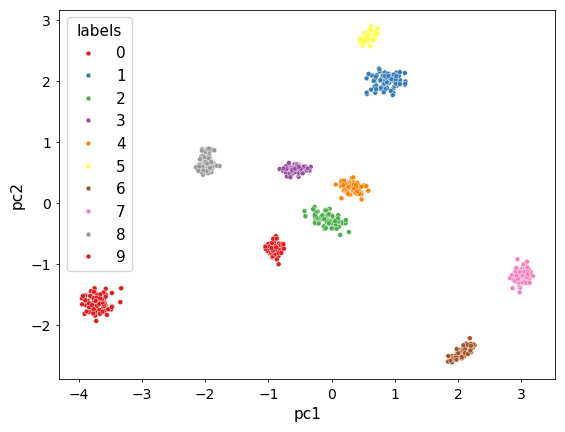

In [16]:
train,test,labels_train,labels_test,pca=scale_for_pca(dataset_high)

2026-07-01 13:09:55,584	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-07-01 13:09:55,586	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-07-01 13:10:33,837	INFO tune.py:1001 -- Wrote the latest version of all result files and 

(_sweep_trainable pid=3972001) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/gaussians/sweep_0/medal_pca2_2_seed1_ckpts/final.pt


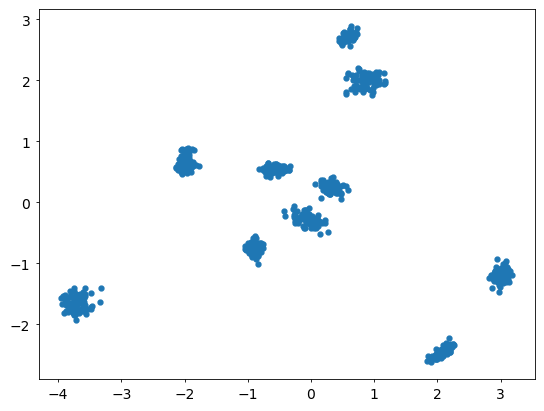

In [17]:
model, recon_loss=find_best_MEDAL(train,noise_d)

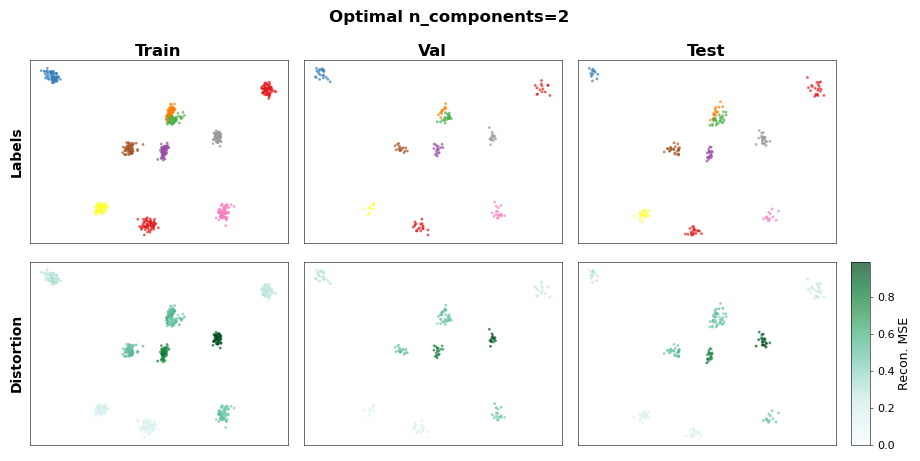

In [12]:
plot_MEDAL(noise_d,labels_train,test,labels_test)

In [61]:
print_MEDAL_pca_recon(recon_loss,pca,train)

0.4160486282843478 0.4160409684337289


Using 128 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|████████████████████████████████████████| 200/200 [00:10<00:00, 19.36it/s]


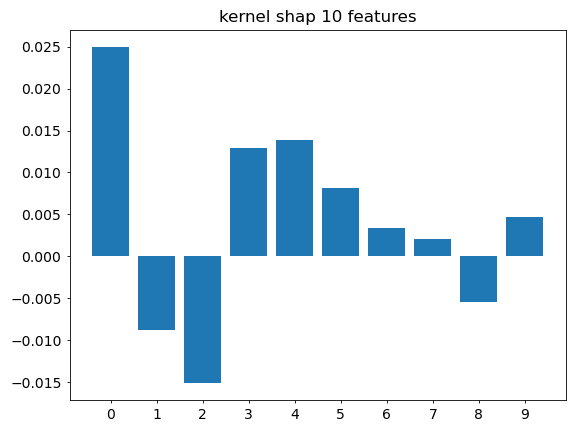

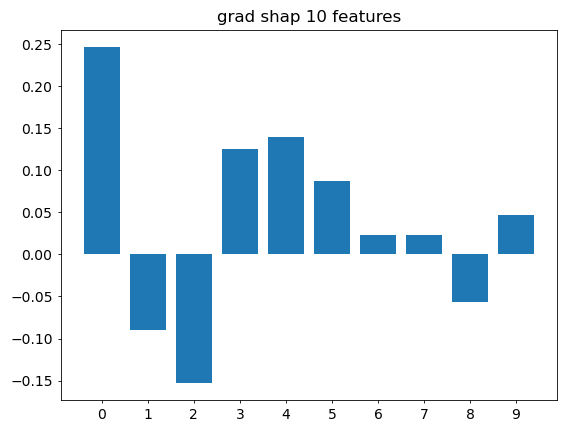

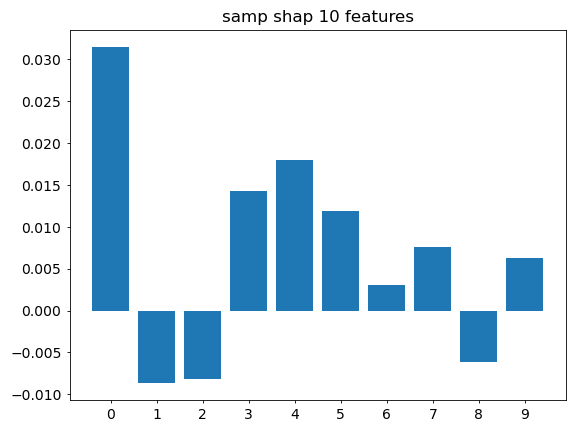

In [13]:
with open(f"simulations-MEDAL/gaussians/model_{noise_d}_pca.pkl",'rb') as file:
    model=pickle.load(file)
kernel_shap,grad_shap,samp_shap=shap_recall(model,train,test)

In [11]:
### simulated gaussians noise_d=10
k=10
sample_size=1000
low_d=2
signal_d=10
noise_d=10


## noise_d=10
dataset_high, labels, _, _ =build_simple_k_clusters(k, sample_size, signal_d,  noise_d)

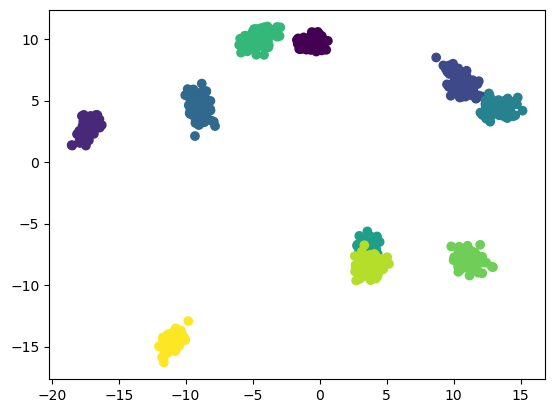

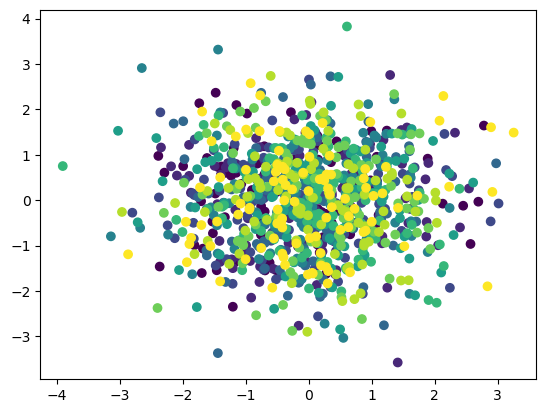

In [12]:
plot_signal_noise(dataset_high,labels)

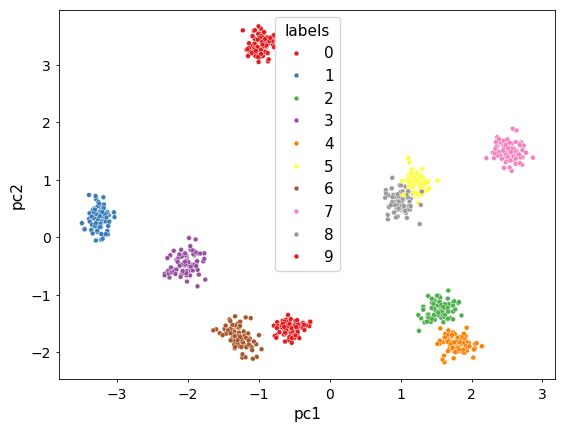

In [18]:
train,test,labels_train,labels_test,pca=scale_for_pca(dataset_high)

2026-06-30 23:39:10,056	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-06-30 23:39:10,058	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.


(_sweep_trainable pid=3308745) Saved model to /insomnia001/depts/iicd/users/vj2308/LXDR/LXDR/simulations-MEDAL/gaussians/sweep_10/medal_pca2_2_seed0_ckpts/final.pt


2026-06-30 23:39:33,453	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/insomnia001/depts/iicd/users/vj2308/LXDR/LXDR/simulations-MEDAL/gaussians/sweep_10/ray_results/medal_teacher_sweep' in 0.0060s.


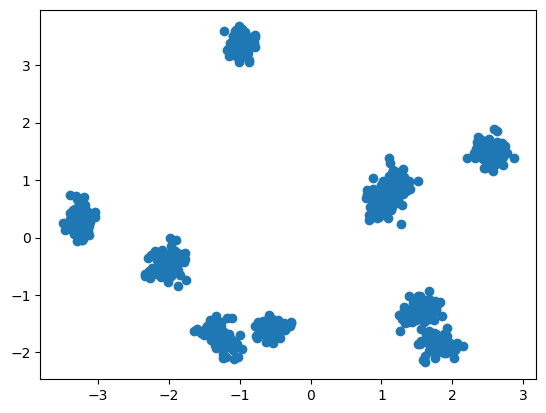

In [14]:
model, recon_loss=find_best_MEDAL(train,noise_d)

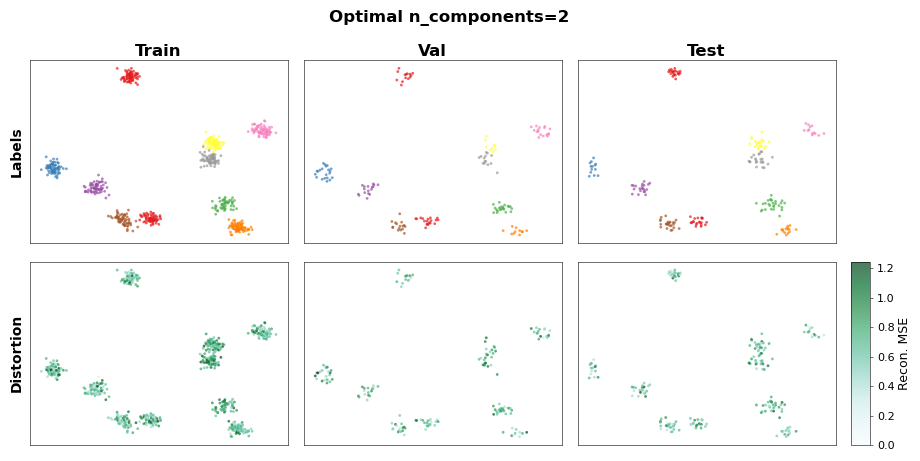

In [15]:
plot_MEDAL(noise_d,labels_train,test,labels_test)

In [19]:
print_MEDAL_pca_recon(recon_loss,pca,train)

0.7136840696846857 0.713680871455088


Using 128 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|████████████████████████████████████████| 200/200 [00:25<00:00,  7.97it/s]


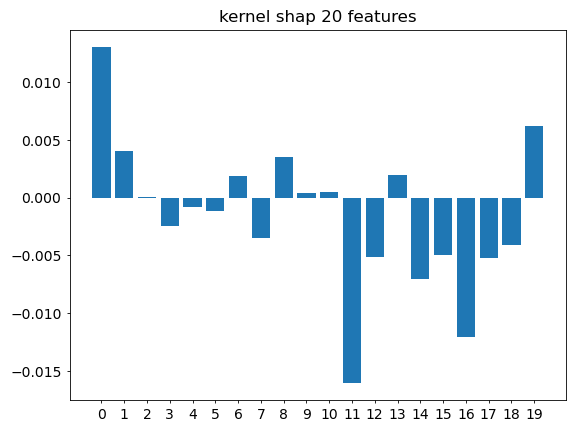

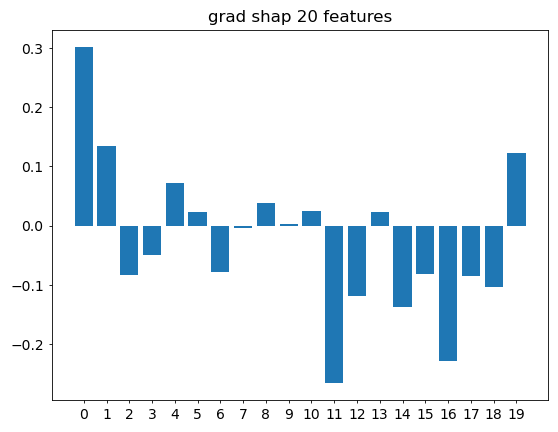

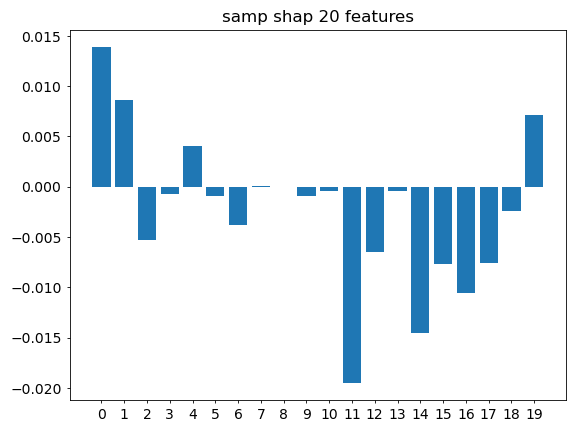

In [37]:
with open("simulations-MEDAL/gaussians/model_10_pca.pkl",'rb') as file:
    model=pickle.load(file)
kernel_shap,grad_shap,samp_shap=shap_recall(model,train,test)

In [38]:
### simulated gaussians noise_d=20
k=10
sample_size=1000
low_d=2
signal_d=10
noise_d=20


## noise_d=10
dataset_high, labels, _, _ =build_simple_k_clusters(k, sample_size, signal_d,  noise_d)

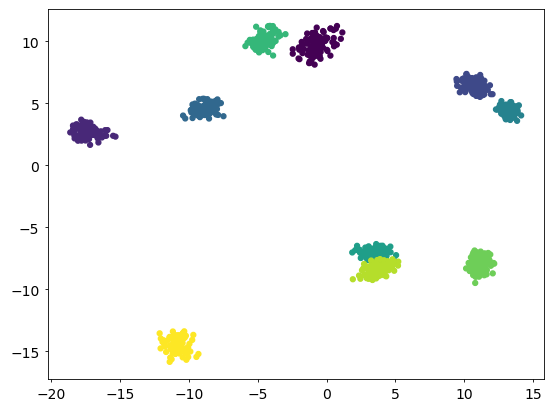

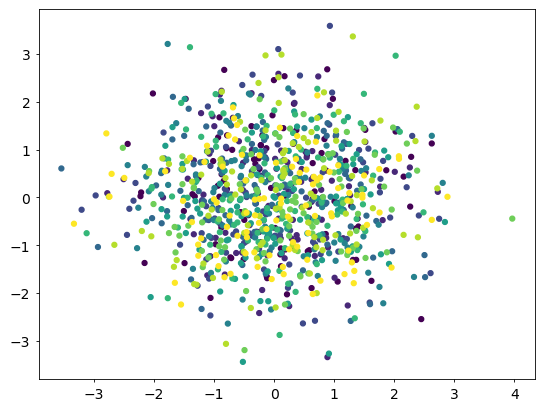

In [39]:
plot_signal_noise(dataset_high,labels)

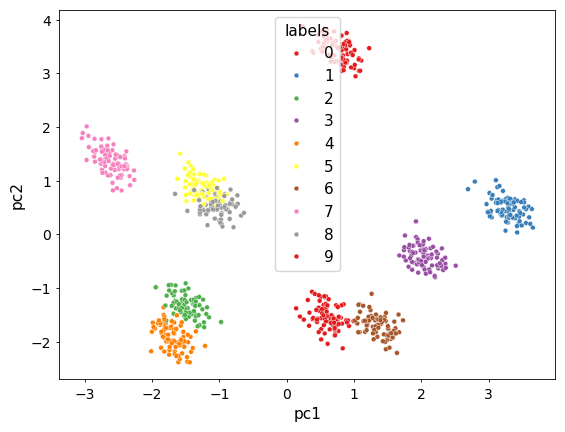

In [41]:
train,test,labels_train,labels_test,pca=scale_for_pca(dataset_high)

2026-07-01 00:00:59,236	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-07-01 00:00:59,238	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-07-01 00:01:23,982	INFO tune.py:1001 -- Wrote the latest version of all result files and 

(_sweep_trainable pid=3358851) Saved model to /insomnia001/depts/iicd/users/vj2308/LXDR/LXDR/simulations-MEDAL/gaussians/sweep_20/medal_pca2_2_seed0_ckpts/final.pt
(_sweep_trainable pid=3358915) Saved model to /insomnia001/depts/iicd/users/vj2308/LXDR/LXDR/simulations-MEDAL/gaussians/sweep_20/medal_pca2_2_seed1_ckpts/final.pt


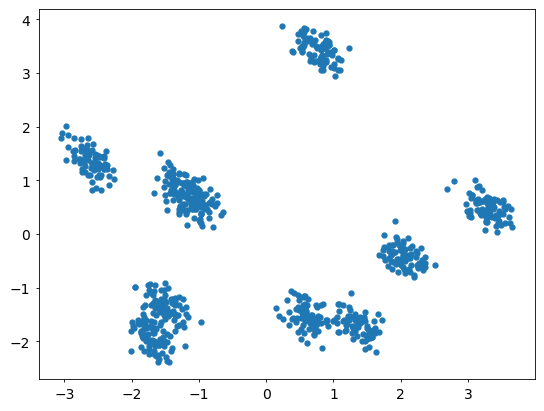

In [42]:
model, recon_loss=find_best_MEDAL(train,noise_d)

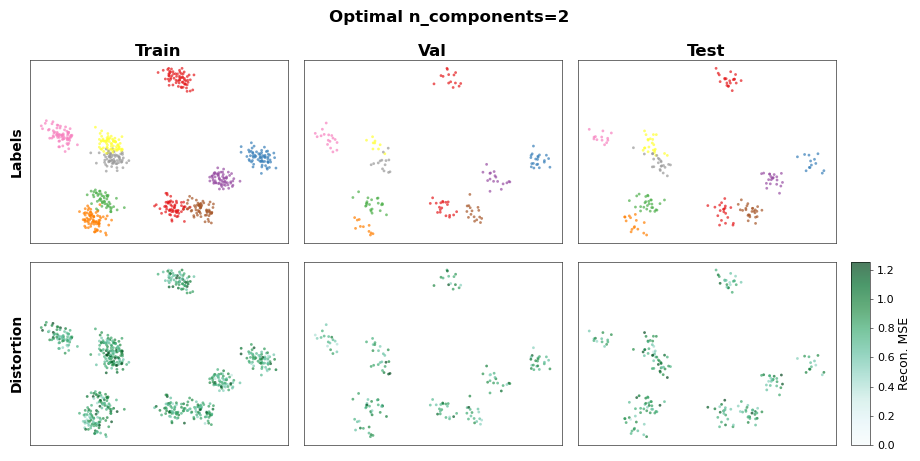

In [43]:
plot_MEDAL(noise_d,labels_train,test,labels_test)

In [44]:
print_MEDAL_pca_recon(recon_loss,pca,train)

0.8029732019804644 0.8029485464624262


Using 128 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|████████████████████████████████████████| 200/200 [00:28<00:00,  6.95it/s]


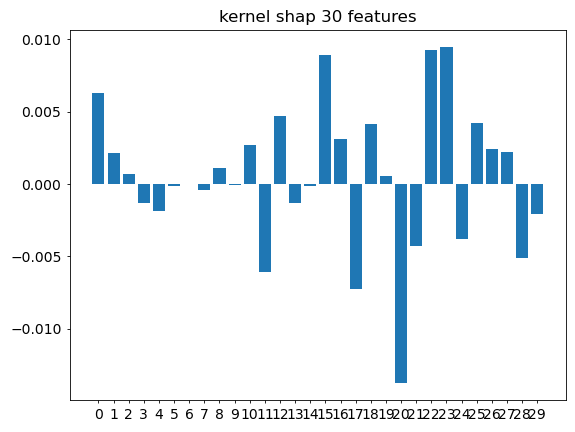

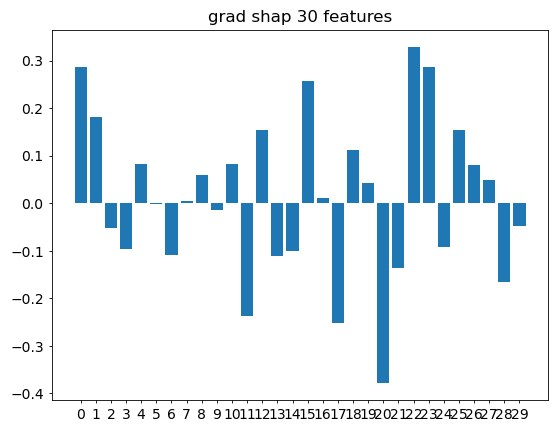

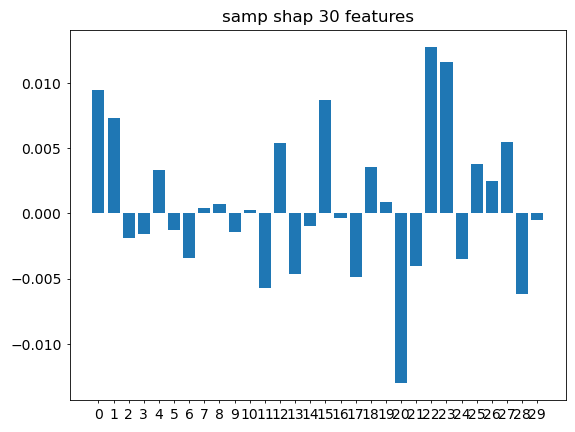

In [47]:
with open(f"simulations-MEDAL/gaussians/model_{noise_d}_pca.pkl",'rb') as file:
    model=pickle.load(file)
kernel_shap,grad_shap,samp_shap=shap_recall(model,train,test)

In [48]:
### simulated gaussians noise_d=50
k=10
sample_size=1000
low_d=2
signal_d=10
noise_d=50


## noise_d=10
dataset_high, labels, _, _ =build_simple_k_clusters(k, sample_size, signal_d,  noise_d)

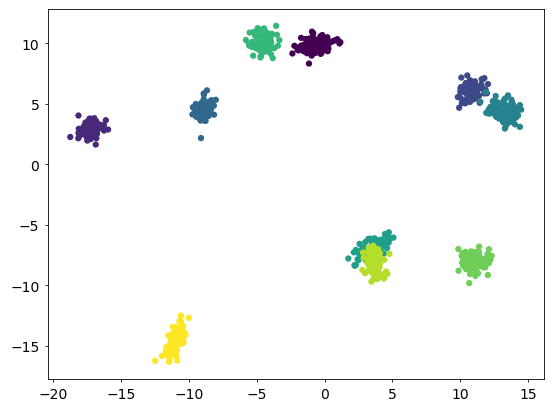

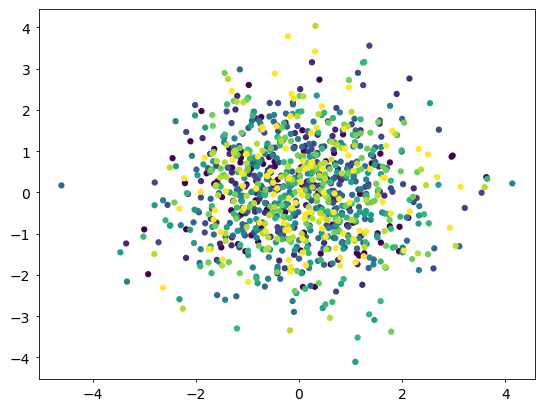

In [49]:
plot_signal_noise(dataset_high,labels)

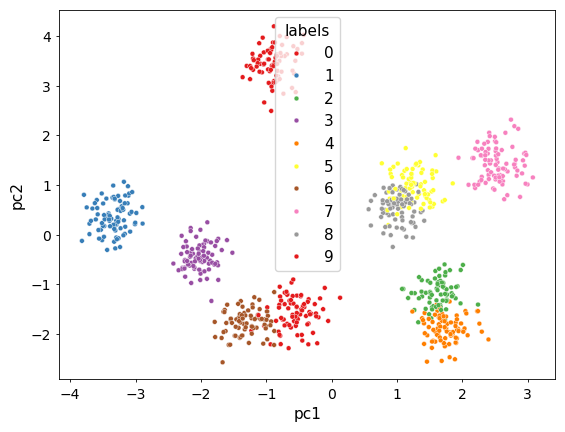

In [51]:
train,test,labels_train,labels_test,pca=scale_for_pca(dataset_high)

2026-07-01 00:09:50,691	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-07-01 00:09:50,697	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.


(_sweep_trainable pid=3380315) Saved model to /insomnia001/depts/iicd/users/vj2308/LXDR/LXDR/simulations-MEDAL/gaussians/sweep_50/medal_pca2_2_seed0_ckpts/final.pt


2026-07-01 00:10:15,224	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/insomnia001/depts/iicd/users/vj2308/LXDR/LXDR/simulations-MEDAL/gaussians/sweep_50/ray_results/medal_teacher_sweep' in 0.0072s.


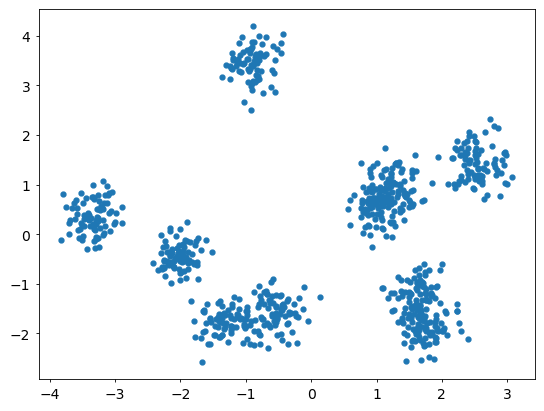

In [52]:
model, recon_loss=find_best_MEDAL(train,noise_d)

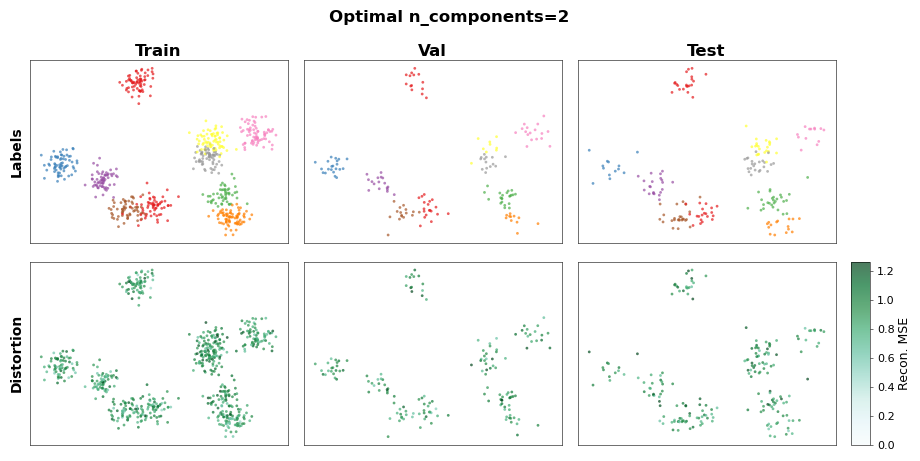

In [53]:
plot_MEDAL(noise_d,labels_train,test,labels_test)

In [54]:
print_MEDAL_pca_recon(recon_loss,pca,train)

0.8963084256562854 0.8962960544178978


Using 128 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|████████████████████████████████████████| 200/200 [00:51<00:00,  3.86it/s]


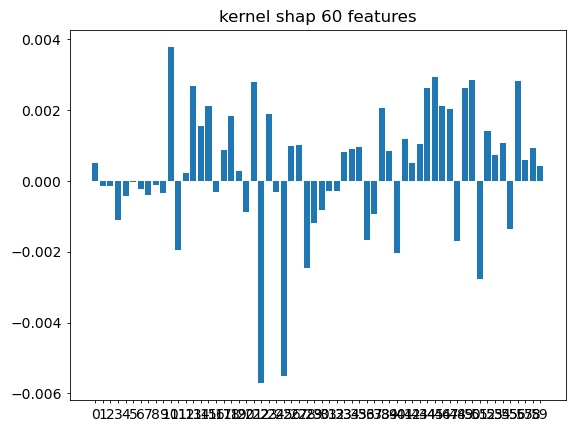

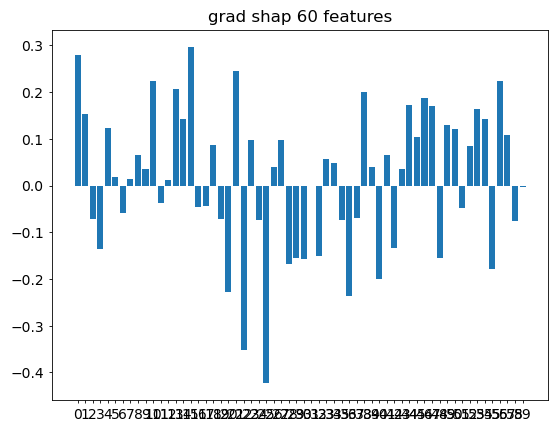

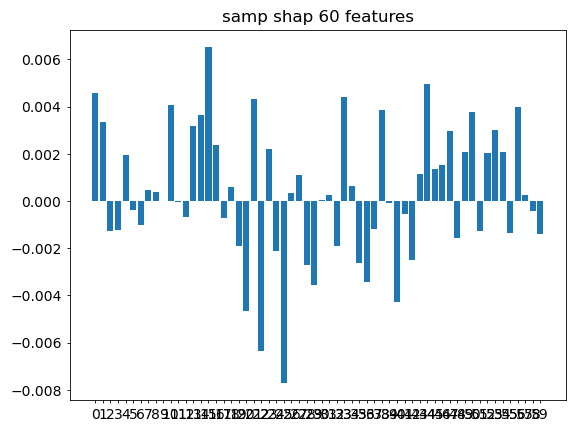

In [55]:
with open(f"simulations-MEDAL/gaussians/model_{noise_d}_pca.pkl",'rb') as file:
    model=pickle.load(file)
kernel_shap,grad_shap,samp_shap=shap_recall(model,train,test)